In [84]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [86]:
#Zdefiniowanie baz pomiarowych
b0 = np.array([1, 0]) # |0>
b1 = np.array([0, 1]) # |1>
b2 = np.array([1/math.sqrt(2), 1/math.sqrt(2)]) # |+>
b3 = np.array([1/math.sqrt(2), -1j/math.sqrt(2)]) # |-i> - nie pamietam czy + czy - i teraz xdd

b = [b0, b1, b2, b3]

#Zdefiniowanie bazy macierzy gestosci
g0 = np.array([[1, 0], [0, 1]]) #jednostkowa
g1 = np.array([[0, 1], [1, 0]]) #sigma x
g2 = np.array([[0, -1j], [1j, 0]]) #sigma y 
g3 = np.array([[1, 0], [0, -1]]) #sigma z

g = [g0, g1, g2, g3]

In [88]:
#Rozszerzenie bazy na N qubitow
from itertools import product

N = 1  # liczba qubitow

b_big = []              # pełne wektory N-qubitowe
g_big = []              # pelne macierze N-qubitowe
structure = []          # zapis struktury (które stany 1q tworzą dany stan)

#Stworzenie wszystkich kombinacji stanów z bazy żeby była pełna przestrzeń N qubitowa
for combo_indices in product(range(len(b)), repeat=N):

    # zapisz strukturę (np. (0,3)) - tu jest tworzenie obiektu ktory trzyma info o małych wektorach budujących dany duzy wektor
    structure.append(combo_indices)

    # pierwszy czynnik
    result_b = b[combo_indices[0]]
    result_g = g[combo_indices[0]]

    # kolejne czynniki tensora - zwyczajny iloczyn tensorowy zeby powiekszyc przestrzen odpowiednimi malymi wektorami/macierzami
    for idx in combo_indices[1:]:
        result_b = np.kron(result_b, b[idx])
        result_g = np.kron(result_g, g[idx])

    b_big.append(result_b)
    g_big.append(result_g)

m = np.zeros(len(structure))
b_big = np.array(b_big)
g_big = np.array(g_big)
print(b_big.shape)
print(g_big.shape)

(4, 2)
(4, 2, 2)


In [90]:
#Wyliczenie macierzy B oraz jej odwrócenie
B = np.zeros((b_big.shape[0], b_big.shape[0]), dtype=complex)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        B[i, j] = np.conjugate(b_big[i]).T @ g_big[j] @ b_big[i]

print(B)

B_inv = np.linalg.inv(B)

print(B_inv)

[[ 1.+0.j  0.+0.j  0.+0.j  1.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 1.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 1.+0.j  0.+0.j -1.+0.j  0.+0.j]]
[[ 0.5+0.j  0.5+0.j  0. +0.j  0. +0.j]
 [-0.5+0.j -0.5+0.j  1. +0.j  0. +0.j]
 [ 0.5+0.j  0.5+0.j  0. -0.j -1. -0.j]
 [ 0.5+0.j -0.5-0.j  0. -0.j  0. -0.j]]


In [96]:
def genQST(state_qc, circuits_temp, circuits_unstrans_temp):
    for combo in structure:
        #Budowanie czesci obwodu odpowiedzialnej za pomiar, czyli obrot qubitow do dobrej bazy i pomiar w bazie Z
        mes_qc = qiskit.QuantumCircuit(N,N)

        #Przejechanie przez wszystkie elementy duzej bazy i rozkodowanie kazdego na bazy 1 qubitowe oraz obrot do bazy Z
        for i in range(len(combo)):
            if combo[i] == 1:
                mes_qc.x(i)
            elif combo[i] == 2:
                mes_qc.h(i)
            elif combo[i] == 3:
                mes_qc.s(i)
                mes_qc.h(i)

        #Zlozenie pelnego obwodu oraz transpilacja
        complete_qc = QuantumCircuit(N,N)
        complete_qc = complete_qc.compose(state_qc)
        complete_qc.barrier()
        complete_qc = complete_qc.compose(mes_qc)
        complete_qc.measure(range(N),range(N))

        
        circuits_unstrans_temp.append(complete_qc.copy())

        if(backend.name == "aer_simulator_from(IQMBackend)" or backend.name == "IQMBackend"):
            complete_qc = transpile(complete_qc, backend=backend, initial_layout=[0], layout_method="trivial", optimization_level=3)
        else:
            complete_qc = transpile(complete_qc, backend=backend, optimization_level=3, scheduling_method="alap")

        #Dodanie pelnego obwodu wykonujacego dany pomiar stanu psi do listy obwodow do puszczenia
        circuits_temp.append(complete_qc.copy())

def prepcircuitstosave(circuits_temp):
    if(backend.name == "aer_simulator_from(IQMBackend)" or backend.name == "IQMBackend"):
        dt = 1e-9 #1e-9
    else:
        dt = backend.dt

    for circuit in circuits_temp:
        for i, inst in enumerate(circuit.data):
            op = inst.operation

            if isinstance(op, Delay) and not op.is_parameterized():

                # konwersja do dt
                if op.unit == "dt":
                    duration_dt = int(round(op.duration))
                else:
                    unit_scale = {
                        "s": 1,
                        "ms": 1e-3,
                        "us": 1e-6,
                        "ns": 1e-9,
                        "ps": 1e-12,
                    }
                    duration_seconds = float(op.duration) * unit_scale[op.unit]
                    duration_dt = int(round(duration_seconds / dt))

                # tworzymy nowy Delay w dt
                new_delay = Delay(duration_dt, unit="dt")

                # zamieniamy w circuit
                from qiskit.circuit import CircuitInstruction
                circuit.data[i] = CircuitInstruction(operation=new_delay,
                                                          qubits=inst.qubits,
                                                          clbits=inst.clbits)

def printcircuits(circuits_temp):
    for i in circuits_temp:
        i.draw(output='mpl')
        plt.show()

In [98]:
#Przygotowanie ukladow do tomografii
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakePerth, FakeKyiv
from iqm.qiskit_iqm import IQMProvider
import os


token = os.getenv("OdraToken")
#print(token)
iqm_server_url = "https://odra5.e-science.pl/"
backend = IQMProvider(iqm_server_url, token=token).get_backend()

#backend = AerSimulator.from_backend(backend)

#backend = AerSimulator.from_backend(FakeKyiv())

#print(backend.dt)

import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Delay

# Przygotowanie stanu
#obliczenia na qubitach 1,3
qc1 = qiskit.QuantumCircuit(N,N)
qc2 = qiskit.QuantumCircuit(N,N)
qc3 = qiskit.QuantumCircuit(N,N)
qc4 = qiskit.QuantumCircuit(N,N)
#Stworzenie stanu
qc1.h(0)
#qc1.cx(0,1)

qc2.h(0)
#qc2.cx(0,1)

qc3.h(0)
#qc3.cx(0,1)

qc4.h(0)
#qc4.cx(0,1)

#dt to ns
qc2.delay(4, range(N), unit='us')
qc3.delay(8, range(N), unit='us')
qc4.delay(16, range(N), unit='us')


# Zrobienie obwodow do puszczenia
circuits = []
circuits_untranspiled = []
#genQST(qc1, circuits, circuits_untranspiled)
#genQST(qc2, circuits, circuits_untranspiled)
genQST(qc3, circuits, circuits_untranspiled)
#genQST(qc4, circuits, circuits_untranspiled)


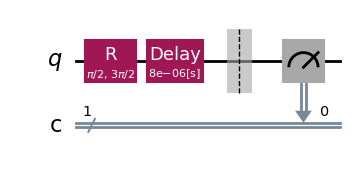

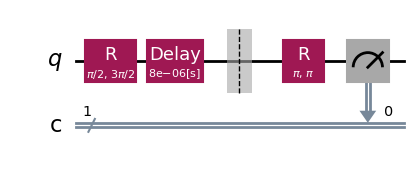

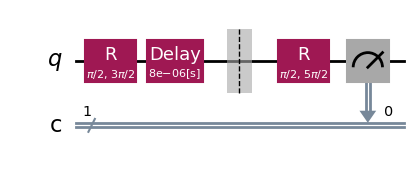

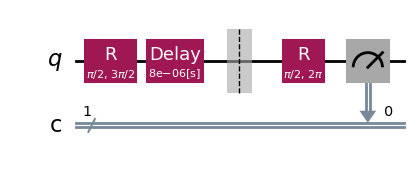

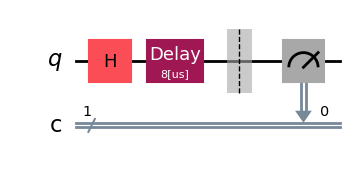

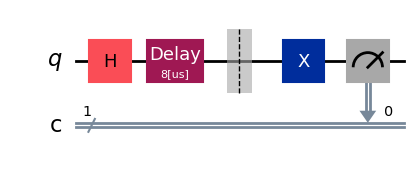

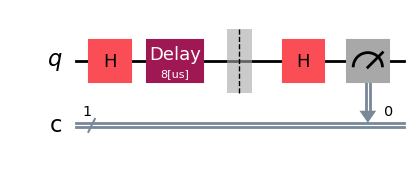

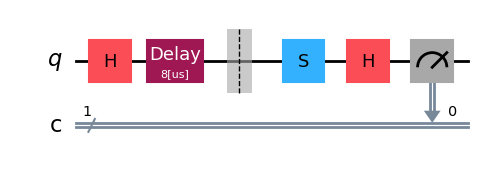

In [100]:
printcircuits(circuits)
printcircuits(circuits_untranspiled)

In [102]:
# Wykonanie obwodow
# Czasy:
# 1 qubit 1000 - 2s
# 1 qubit 10000 - 17s
# 2 qubity 1000 - 7s

job = backend.run(circuits, shots=1000)  # lista obwodów
result = job.result()

# Zaladowanie wynikow
m_full = []
for i in range(len(circuits)):
    counts = result.get_counts(i)
    zero_state = '0' * N
    m_full.append(counts.get(zero_state, 0) / sum(counts.values()))

print(m_full)


#Zapis do plikow
from datetime import datetime
from pathlib import Path
import qiskit.qpy as qpy
import re

timestamp = datetime.now().strftime("%Y-%m-%d")

folder = Path("Runs_"+timestamp)
folder.mkdir(exist_ok=True)

files_test = list(folder.glob(f"*circuits*.qpy"))
#print(files_test)

used_numbers = list()

for f in files_test:
    me = re.match(r"(\d+)_circuits", f.name)
    if me:
        used_numbers.append(int(me.group(1)))

number = 1
for i in range(len(used_numbers)):
    if (number == used_numbers[i]):
        number = used_numbers[i]+1

filename1 = f"{number}_circuits_{len(circuits)}.qpy"
filename2 = f"{number}_circuitsraw_{len(circuits_untranspiled)}.qpy"
filename3 = f"{number}_counts_{len(circuits)}.json"

prepcircuitstosave(circuits)
prepcircuitstosave(circuits_untranspiled)

with open(folder / filename1, "wb") as f:
    qpy.dump(circuits, f)
with open(folder / filename2, "wb") as f:
    qpy.dump(circuits_untranspiled, f)

all_counts = [result.get_counts(i) for i in range(len(circuits))]
with open(folder / filename3, "w") as f:
    json.dump(all_counts, f, indent=2)

Progress in queue:   0%|          | 0/2 [00:00<?, ?it/s]

[0.774, 0.268, 0.533, 0.282]


In [21]:
#Odczyt z plikow
import glob
from pathlib import Path
import qiskit.qpy as qpy

#Tutaj sie podaje numer pliku w folderze i folder
numer = "1"
folder = "Runs_2026-03-30"

file1 = list(Path(folder).glob(f"{numer}_circuits_*.qpy"))[0]
file2 = list(Path(folder).glob(f"{numer}_circuitsraw_*.qpy"))[0]
file3 = list(Path(folder).glob(f"{numer}_counts_*.json"))[0]

circuits = []
circuits_untranspiled = []
all_counts = []


with open(file1, "rb") as f:
    circuits = qpy.load(f)
with open(file2, "rb") as f:
    circuits_untranspiled = qpy.load(f)
with open(file3) as f:
    all_counts = json.load(f)

m_full = np.zeros(len(all_counts))
        
for i in range(len(all_counts)):
    counts = all_counts[i]
    zero_state = '0' * N
    m_full[i] = counts.get(zero_state, 0) / sum(counts.values())

print(m_full)

[0.5   0.    0.258 0.23  0.    0.5   0.255 0.236 0.25  0.246 0.506 0.269
 0.282 0.255 0.244 0.    0.484 0.    0.247 0.244 0.    0.532 0.228 0.246
 0.26  0.256 0.481 0.272 0.233 0.271 0.259 0.    0.504 0.    0.257 0.248
 0.    0.512 0.27  0.265 0.241 0.225 0.491 0.262 0.263 0.255 0.253 0.
 0.49  0.    0.239 0.24  0.    0.482 0.27  0.259 0.218 0.257 0.488 0.245
 0.257 0.243 0.252 0.   ]


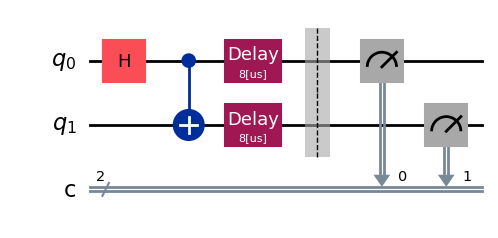

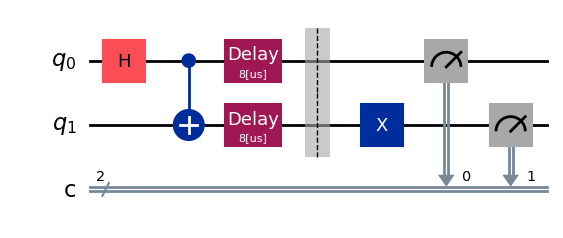

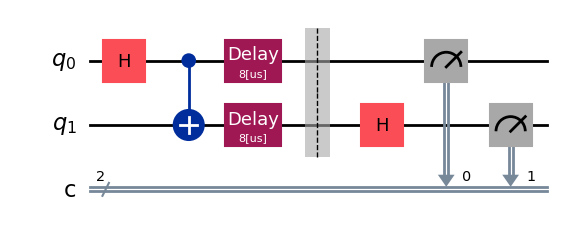

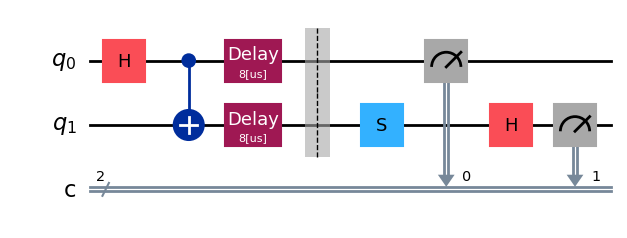

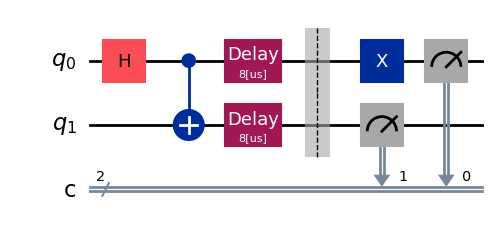

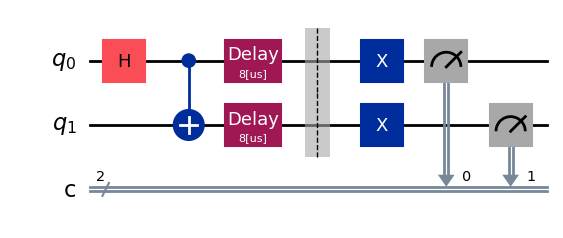

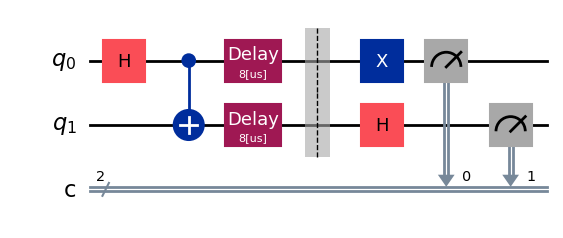

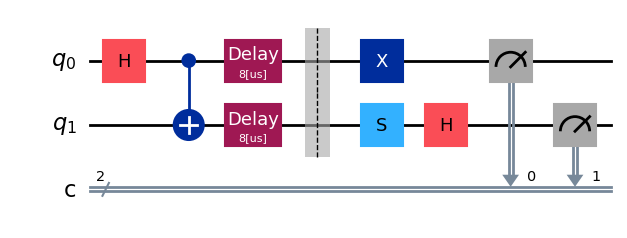

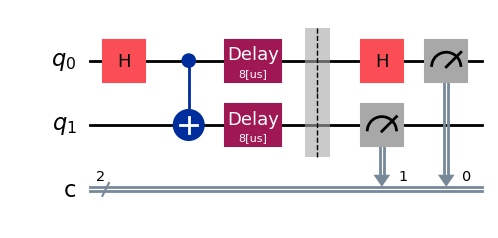

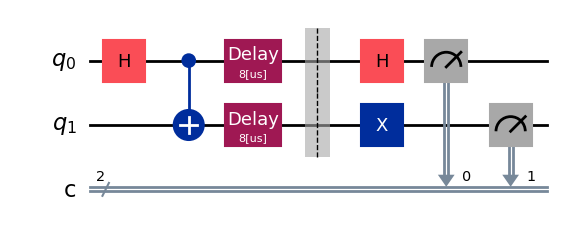

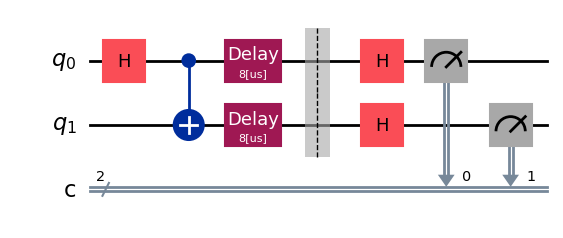

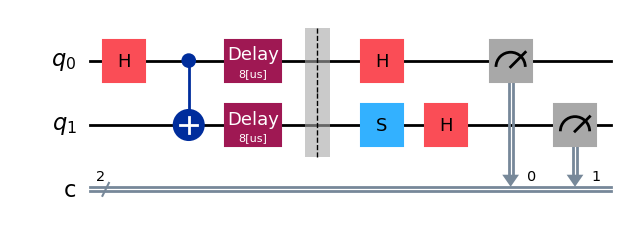

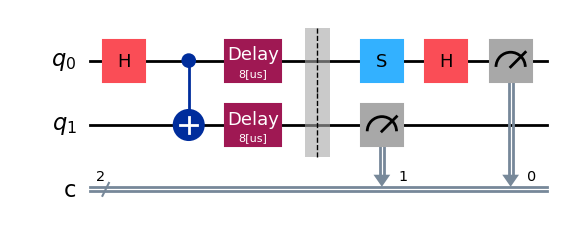

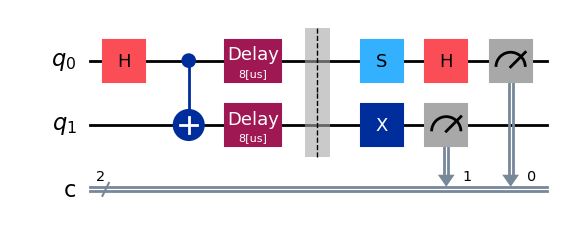

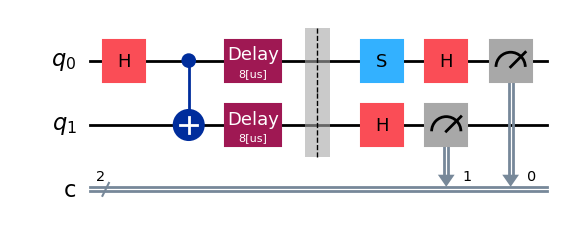

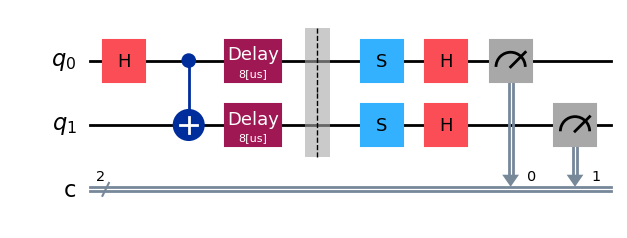

In [28]:
printcircuits(circuits_untranspiled)

In [25]:
#Wziecie odpowiednich wynikow pomiarow z m_full do m
A = 3 #Tutaj wpisanie ktory blok
for i in range(len(m)):
    m[i] = m_full[i+A*len(m)]

print(m)

[0.49  0.    0.239 0.24  0.    0.482 0.27  0.259 0.218 0.257 0.488 0.245
 0.257 0.243 0.252 0.   ]


In [27]:
#Rekonstrukcja rho
rho = np.zeros((2**N, 2**N), dtype=complex)
for i in range(g_big.shape[0]):
    rho += g_big[i] * (B_inv @ m)[i]

print(rho)

[[ 0.49  +0.j     -0.006 -0.005j  -0.027 +0.012j   0.4955-0.0085j]
 [-0.006 +0.005j   0.    +0.j     -0.0175-0.0105j  0.016 +0.002j ]
 [-0.027 -0.012j  -0.0175+0.0105j  0.    +0.j      0.029 +0.018j ]
 [ 0.4955+0.0085j  0.016 -0.002j   0.029 -0.018j   0.482 +0.j    ]]


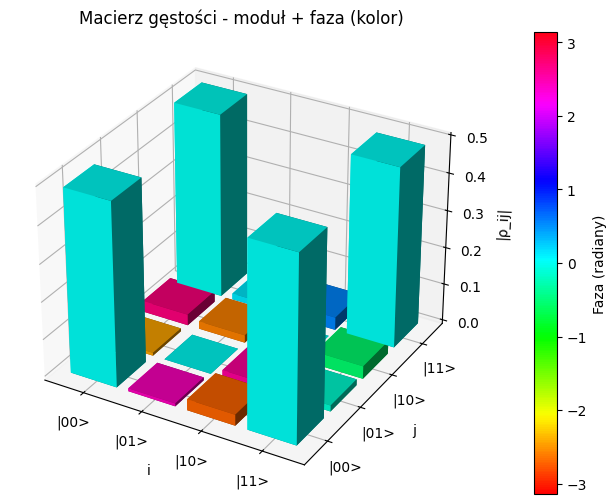

In [29]:
#Narysowanie rho
import matplotlib.pyplot as plt
from matplotlib import cm

n = rho.shape[0]
x = []
y = []
heights = []
colors = []

for i in range(n):
    for j in range(n):
        x.append(i)
        y.append(j)
        heights.append(np.abs(rho[i,j]))
        colors.append(np.angle(rho[i,j]))


# normalizacja fazy -π..π -> 0..1 dla cmap
norm_colors = (np.array(colors) + np.pi) / (2*np.pi)

# wykres 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

bars = ax.bar3d(x, y, np.zeros_like(heights), 0.8, 0.8, heights, color=cm.hsv(norm_colors))

# etykiety osi (stany bazowe)
labels = [f"|{format(i, f'0{N}b')}>"
          for i in range(n)]
ax.set_xticks(np.arange(n) + 0.4)
ax.set_xticklabels(labels)
ax.set_yticks(np.arange(n) + 0.4)
ax.set_yticklabels(labels)

ax.set_xlabel('i')
ax.set_ylabel('j')
ax.set_zlabel('|ρ_ij|')
ax.set_title('Macierz gęstości - moduł + faza (kolor)')

# dodanie legendy fazy
sm = plt.cm.ScalarMappable(cmap=cm.hsv, norm=plt.Normalize(vmin=-np.pi, vmax=np.pi))
cbar = fig.colorbar(sm, ax=ax, pad=0.1)
cbar.set_label('Faza (radiany)')

plt.show()

In [31]:
#Rzeczy do poruszenia (Ziemowit):

#26.02:
#Zapisywanie wyników pomiarów oraz obwodów przed i po transpilacji (moze cos wiecej?) zeby raz narobić danych i potem móc je sobie ładować i badać na różne sposoby
#Ile czasu mamy, a co wazniejsze jak sprawdzic ile zostało? Zeby nie bylo sytuacji ze pusci sie cos duzego i akurat bedzie na wykonczeniu grant. Ja sam wypaliłem z 20s na testach
#w co bedziemy celowac z dzialajaca tomografia? Jakie stany, ile qubitow

#11.03
#Gdansk pokazanie prezki z tomografii: abstrakt
#Papier o tomografii mowil ze ta metoda rekonstrukcji rho moze byc problematyczna gdyz nie zawsze daje macierz gestosci (dodatnia okreslonosc!!)